# Test

Notebook in cui i modelli vengono valutati dallo split di test e comparati fra loro

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT ='/content/drive/MyDrive/Progetto Deep Learning EyeSee'

import os
os.chdir(PROJECT_ROOT)

print("dir corrente ", os.getcwd())

Mounted at /content/drive
dir corrente  /content/drive/.shortcut-targets-by-id/1GF-dviKddmmpH51qxHv7mgdX9c3BQm2s/Progetto Deep Learning EyeSee


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np

SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)

test_dataset=tf.keras.utils.image_dataset_from_directory('data/dataset_split/test',image_size=(224,224),batch_size=32,seed=SEED, shuffle=False)
class_names=test_dataset.class_names

y_true = np.concatenate([y for x, y in test_dataset], axis=0) #crea un array 1d delle etichette vere del modello

Found 633 files belonging to 4 classes.


In [ ]:
MODEL_CONFIGS = {
    "MobileNetV2": {
        "constructor": tf.keras.applications.MobileNetV2,
        "preprocess": tf.keras.applications.mobilenet_v2.preprocess_input,
        "unfreeze_block": "block_16",

    },
    "EfficientNetB0": {
        "constructor": tf.keras.applications.EfficientNetB0,
        "preprocess": tf.keras.applications.efficientnet.preprocess_input,
        "unfreeze_block": "block7a",
    },
    "ResNet50V2": {
        "constructor": tf.keras.applications.ResNet50V2,
        "preprocess": tf.keras.applications.resnet_v2.preprocess_input,
        "unfreeze_block": "conv5_block3",
    },

}

In [ ]:
def test_model(model, model_name):
    predictions=model.predict(test_dataset)
    y_pred=np.argmax(predictions, axis=1) #predizioni

    acc=accuracy_score(y_true,y_pred)
    f1=f1_score(y_true, y_pred, average='weighted') #weighted si basa su il numero di istanze delle classi

    print(f"accuracy: {acc:.4f}\nf1 score: {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)

    fig, ax=plt.subplots(figsize=(9, 6))
    im=ax.imshow(cm, cmap='Blues')

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{model_name}')

    threshold = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > threshold else 'black')

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    fig.savefig(f"results/graphs/confusion_matrix_{model_name}.png", dpi=150, bbox_inches='tight')
    plt.show()
    return acc, f1, cm

In [ ]:
def make_barchart(results_df):
  fig, ax = plt.subplots(figsize=(9, 5))
  x = np.arange(len(results_df.index))
  width = 0.35

  ax.bar(x - width/2, results_df["accuracy"], width, label="Accuracy")
  ax.bar(x + width/2, results_df["f1 score"], width, label="F1 score")

  ax.set_xticks(x)
  ax.set_xticklabels(results_df.index)

  #per zoomare il barchart
  y_min = min(results_df["accuracy"].min(), results_df["f1 score"].min()) - 0.03
  y_max = max(results_df["accuracy"].max(), results_df["f1 score"].max()) + 0.03
  ax.set_ylim(y_min, y_max)

  ax.set_ylabel("Score")
  ax.set_title("Confronto modelli - Accuracy vs F1")
  ax.legend()

  for i, v in enumerate(results_df["accuracy"]):
      ax.text(i - width/2, v + 0.01, f"{v:.3f}", ha='center', fontsize=8)
  for i, v in enumerate(results_df["f1 score"]):
      ax.text(i + width/2, v + 0.01, f"{v:.3f}", ha='center', fontsize=8)

  plt.tight_layout()
  fig.savefig("results/graphs/models_comparison_barchart.png", dpi=150, bbox_inches='tight')
  plt.show()

In [ ]:
results={}

##EyeSeeNet

TESTING di EyeSeeNet



Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,135,950 (11.96 MB)

 Trainable params: 1,045,316 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,090,634 (7.98 MB)

20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step
accuracy: 0.8578
f1 score: 0.8581


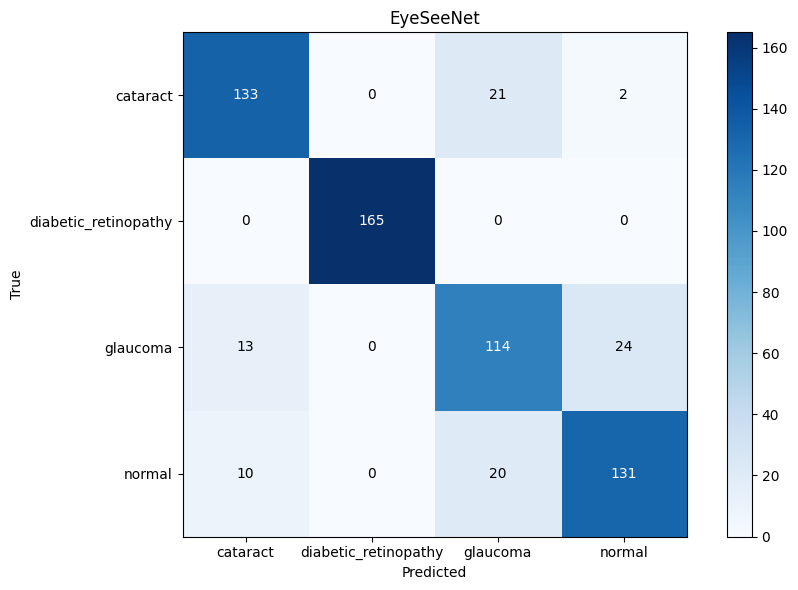

In [ ]:
model_name = "EyeSeeNet"
print(f"TESTING di {model_name}\n")
                                #ultimo modello allenato
model=tf.keras.models.load_model(f"results/models/{model_name}_step3.keras")
model.summary()
acc_es, f1_es, cm_es=test_model(model, model_name)
results[model_name]={"accuracy":acc_es, "f1 score":f1_es}

## MobileNetV2

TESTING di MobileNetV2



Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,244,878 (12.38 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 657,930 (2.51 MB)

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step
accuracy: 0.8752
f1 score: 0.8758


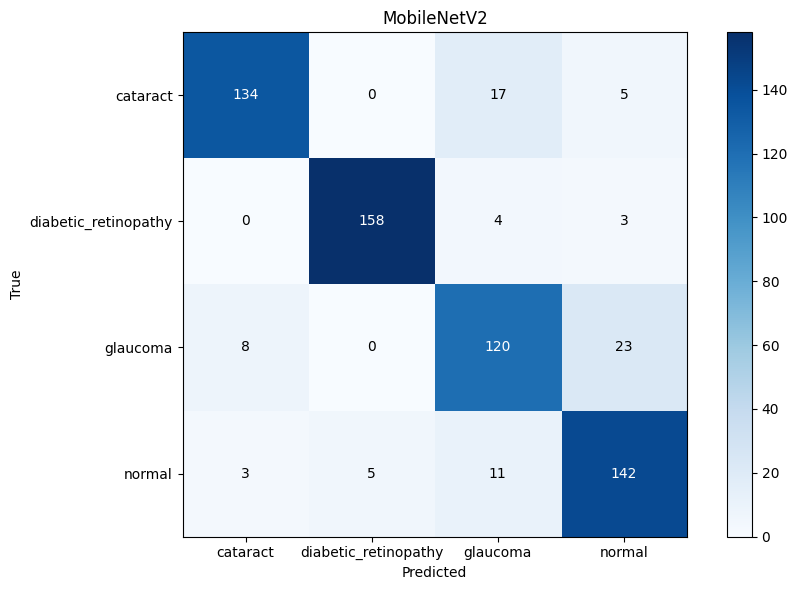

In [ ]:
model_name = "MobileNetV2"
print(f"TESTING di {model_name}\n")
config = MODEL_CONFIGS[f"{model_name}"]
                                #ultimo modello allenato
model=tf.keras.models.load_model(f"results/models/{model_name}_top1.keras",  custom_objects={'preprocess_input':config['preprocess']})
model.summary()
acc_mn, f1_mn, cm_mn=test_model(model, model_name)
results[model_name]={"accuracy":acc_mn, "f1 score":f1_mn}

TESTING di MobileNetV2 finetuned



Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,002,958 (19.08 MB)

 Trainable params: 1,208,004 (4.61 MB)

 Non-trainable params: 1,378,944 (5.26 MB)

 Optimizer params: 2,416,010 (9.22 MB)

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step
accuracy: 0.8768
f1 score: 0.8770


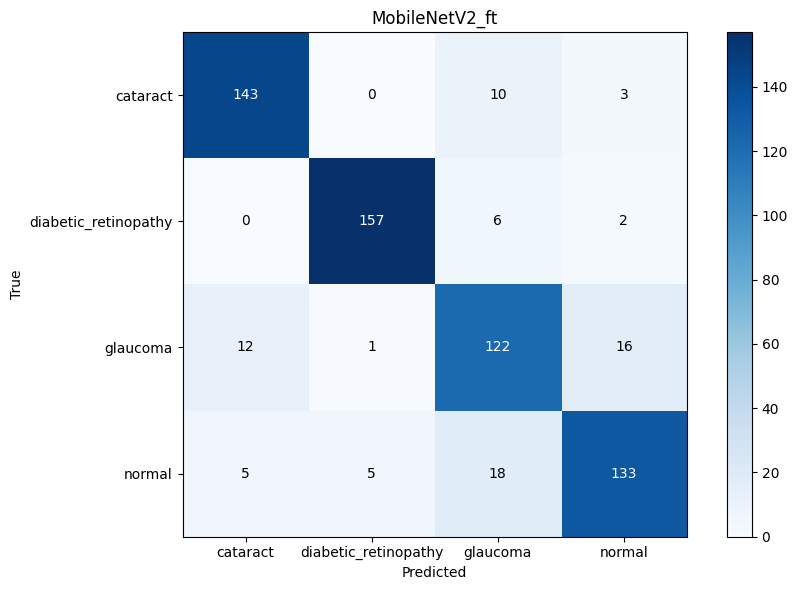

In [ ]:
model_name = "MobileNetV2"
print(f"TESTING di {model_name} finetuned\n")
config = MODEL_CONFIGS[f"{model_name}"]
                                #ultimo modello allenato
model=tf.keras.models.load_model(f"results/models/{model_name}_ip_ft.keras",  custom_objects={'preprocess_input':config['preprocess']})
model.summary()
model_name="MobileNetV2_ft"
acc_mn_ft, f1_mn_ft, cm_mn_ft=test_model(model, model_name)
results[model_name]={"accuracy":acc_mn_ft, "f1 score":f1_mn_ft}

## EfficientNetB0

TESTING di EfficientNetB0



Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,036,465 (19.21 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 657,930 (2.51 MB)

20/20 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step
accuracy: 0.9021
f1 score: 0.9017


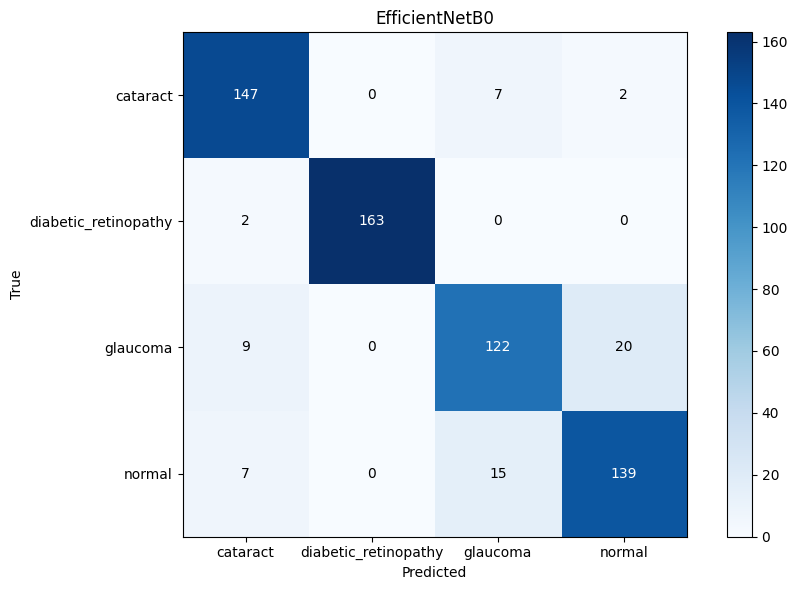

In [ ]:
model_name = "EfficientNetB0"
print(f"TESTING di {model_name}\n")
config = MODEL_CONFIGS[f"{model_name}"]
                                #ultimo modello allenato
model=tf.keras.models.load_model(f"results/models/{model_name}_top2.keras",  custom_objects={'preprocess_input':config['preprocess']})
model.summary()
acc_en, f1_en, cm_en=test_model(model, model_name)
results[model_name]={"accuracy":acc_en, "f1 score":f1_en}

TESTING di EfficientNetB0 finetuned



Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,279,633 (27.77 MB)

 Trainable params: 1,450,548 (5.53 MB)

 Non-trainable params: 2,927,987 (11.17 MB)

 Optimizer params: 2,901,098 (11.07 MB)

20/20 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step
accuracy: 0.9100
f1 score: 0.9103


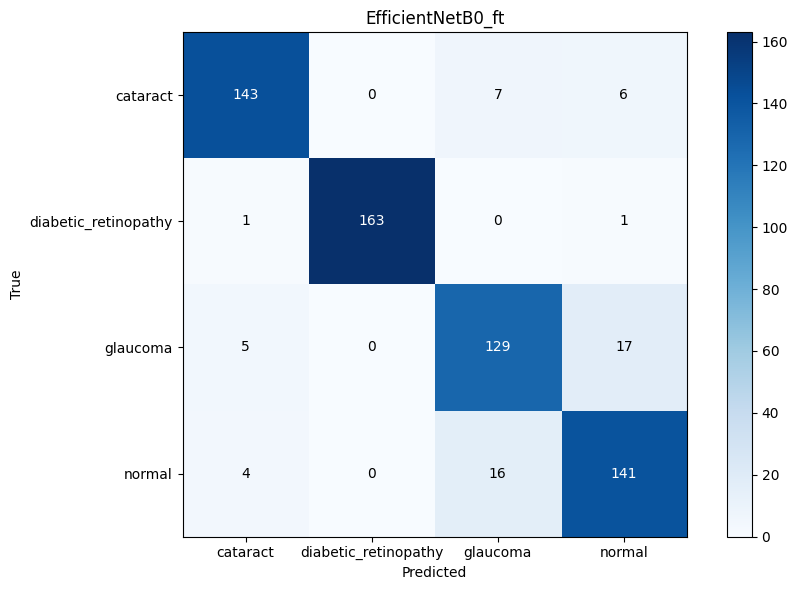

In [ ]:
model_name = "EfficientNetB0"
print(f"TESTING di {model_name} finetuned\n")
config = MODEL_CONFIGS[f"{model_name}"]
                                #ultimo modello allenato
model=tf.keras.models.load_model(f"results/models/{model_name}_ft1.keras",  custom_objects={'preprocess_input':config['preprocess']})
model.summary()
model_name="EfficientNetB0_ft"
acc_en_ft, f1_en_ft, cm_en_ft=test_model(model, model_name)
results[model_name]={"accuracy":acc_en_ft, "f1 score":f1_en_ft}

## ResNet50V2

TESTING di ResNet50V2



Model: "ResNet50V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,141,518 (95.91 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

 Optimizer params: 1,051,146 (4.01 MB)

20/20 ━━━━━━━━━━━━━━━━━━━━ 104s 5s/step
accuracy: 0.8784
f1 score: 0.8787


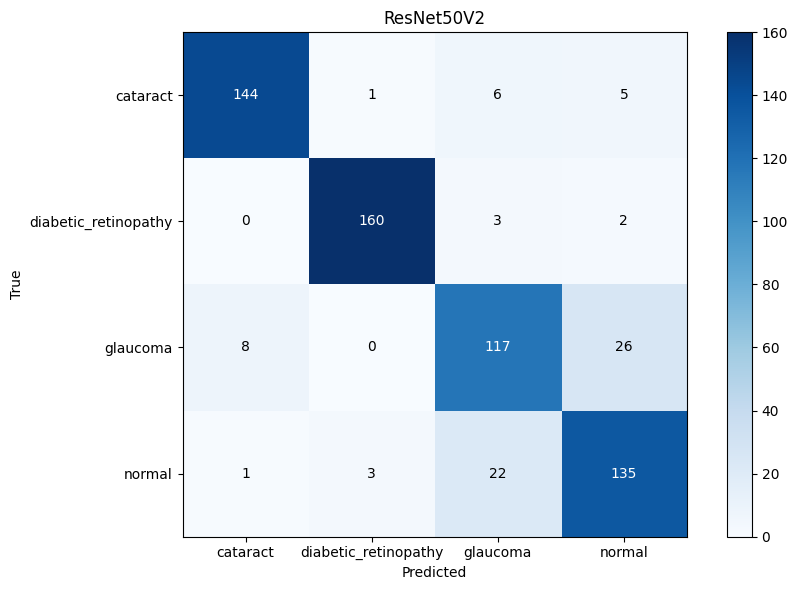

In [ ]:
model_name = "ResNet50V2"
print(f"TESTING di {model_name}\n")
config = MODEL_CONFIGS[f"{model_name}"]
                                #ultimo modello allenato
model=tf.keras.models.load_model(f"results/models/{model_name}_top1.keras",  custom_objects={'preprocess_input':config['preprocess']})
model.summary()
acc_rn, f1_rn, cm_rn=test_model(model, model_name)
results[model_name]={"accuracy":acc_rn, "f1 score":f1_rn}

TESTING di ResNet50V2 finetuned



Model: "ResNet50V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,058,510 (129.92 MB)

 Trainable params: 4,984,068 (19.01 MB)

 Non-trainable params: 19,106,304 (72.88 MB)

 Optimizer params: 9,968,138 (38.03 MB)

20/20 ━━━━━━━━━━━━━━━━━━━━ 104s 5s/step
accuracy: 0.8957
f1 score: 0.8946


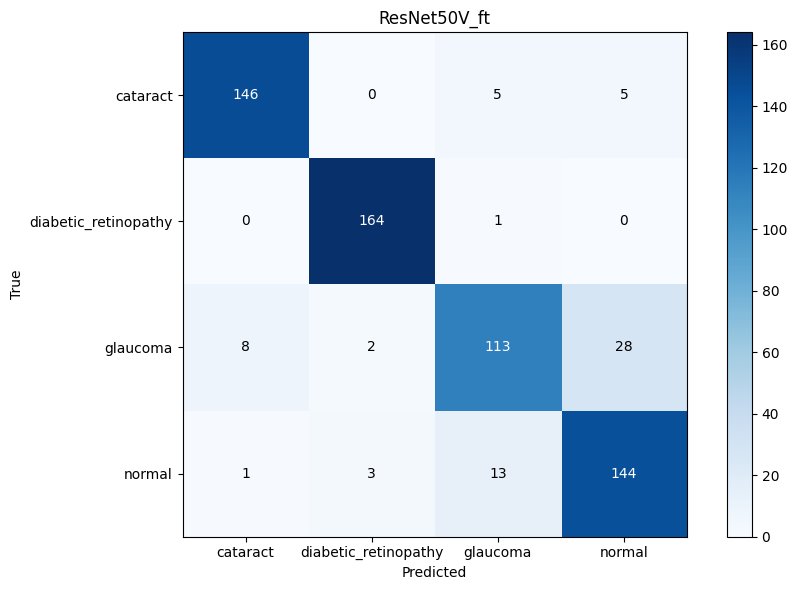

In [ ]:
model_name = "ResNet50V2"
print(f"TESTING di {model_name} finetuned\n")
config = MODEL_CONFIGS[f"{model_name}"]
                                #ultimo modello allenato
model=tf.keras.models.load_model(f"results/models/{model_name}_ip_ft.keras",  custom_objects={'preprocess_input':config['preprocess']})
model.summary()
model_name="ResNet50V_ft"
acc_rn_ft, f1_rn_ft, cm_rn_ft=test_model(model, model_name)
results[model_name]={"accuracy":acc_rn_ft, "f1 score":f1_rn_ft}

##Confronti

In [ ]:
results_df=pd.DataFrame(results).T #traspone righe e colonne
results_df=results_df.sort_values("f1 score", ascending=False)
results_df

,accuracy,f1 score
EfficientNetB0_ft,0.909953,0.910310
EfficientNetB0,0.902054,0.901686
ResNet50V_ft,0.895735,0.894590
ResNet50V2,0.878357,0.878651
MobileNetV2_ft,0.876777,0.876960
MobileNetV2,0.875197,0.875770
EyeSeeNet,0.857820,0.858069


In [ ]:
results_df.to_csv("results/graphs/Models_Compared.csv")

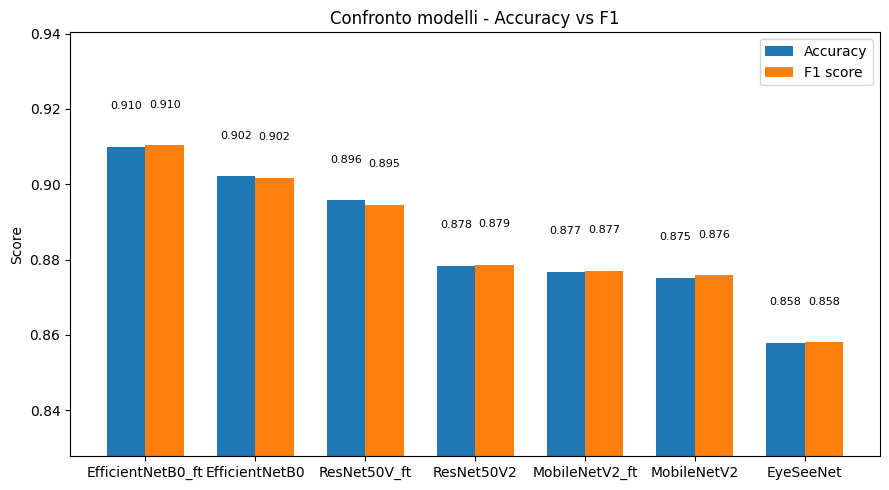

In [ ]:
make_barchart(results_df)